<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
     Deployed predictive ML models (Random Forest,SVM, GBoost, Neural Networks) to optimize catalyst performance and operational parameters
</center></p></h1>

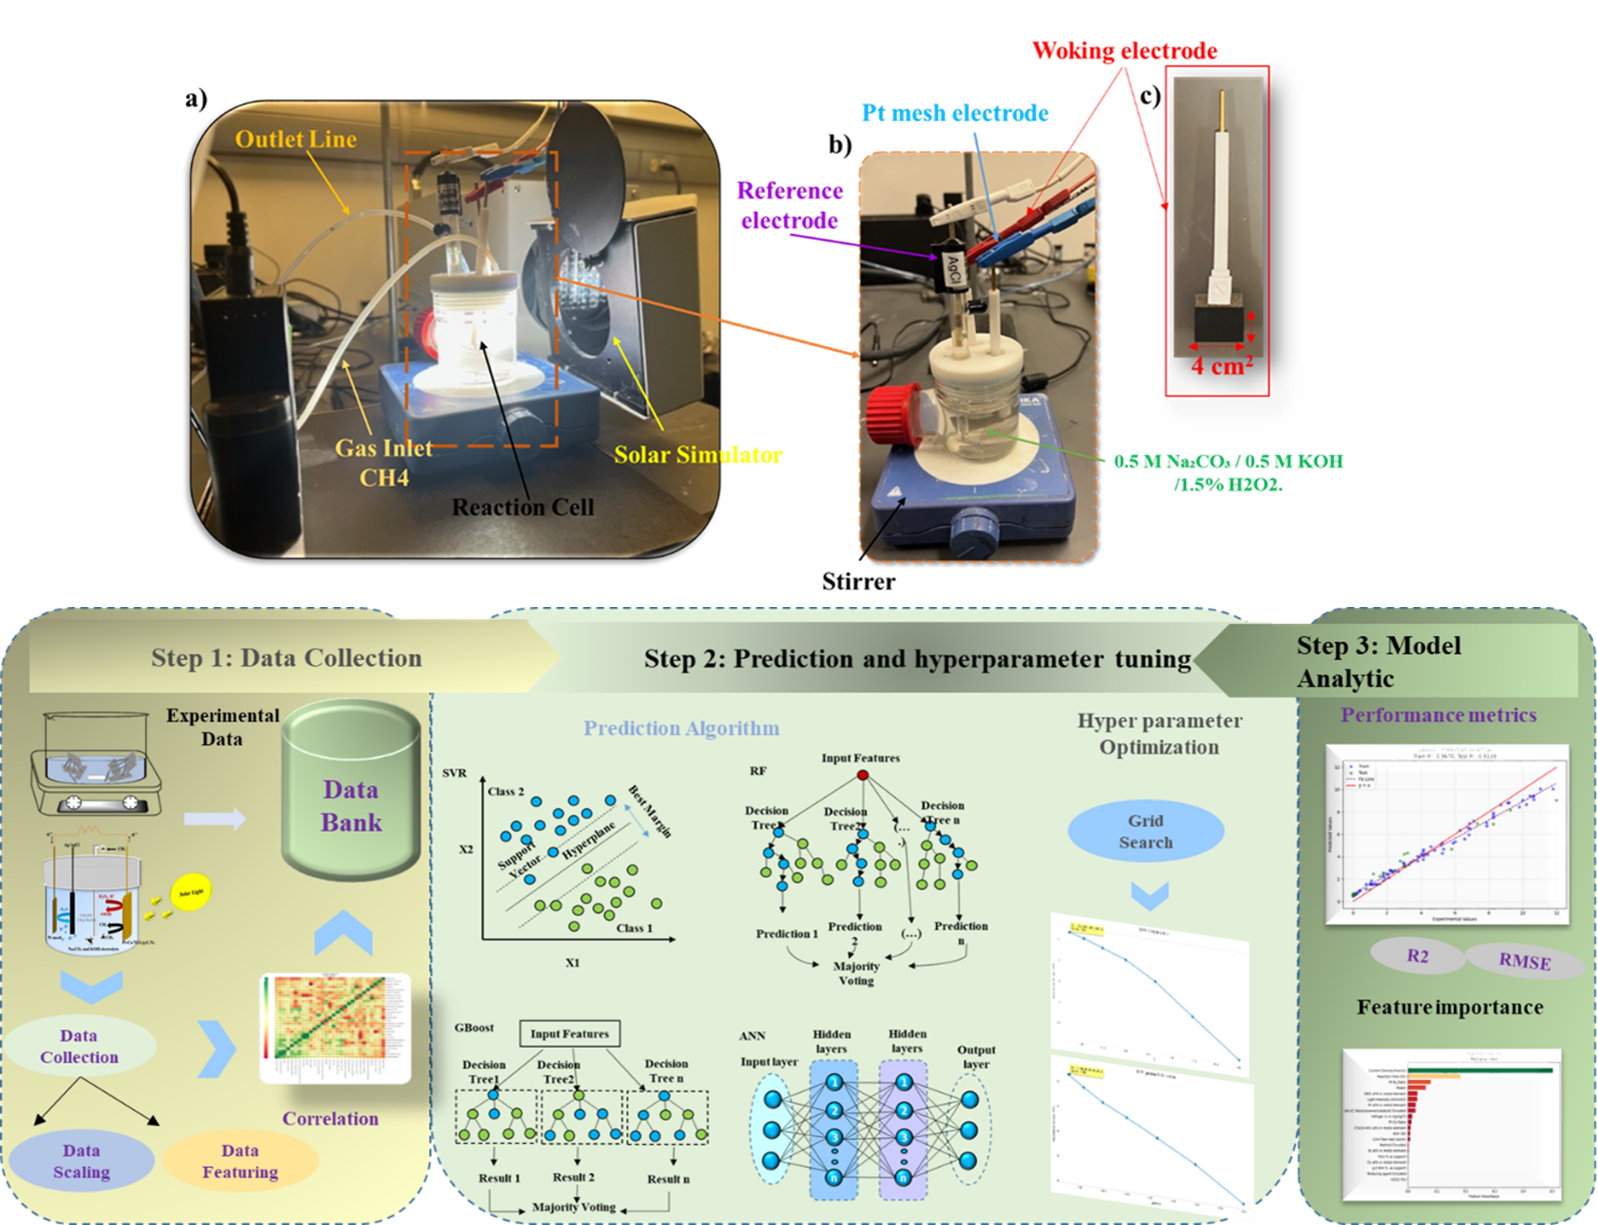

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solid #008000;
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF">
<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> About Dataset </p>
<p style="text-align: justify; font-family: cursive; font-size: 14px; color : black">
This study enhances predictive accuracy in methane electrolysis by introducing polynomial features, interaction terms, and k-fold cross-validation for model optimization. A dataset of 123 rows and 32 key variables—including catalyst composition, applied voltage, current density, and electrolyte concentration—is preprocessed using cleaning, normalization & scaling, and feature selection (correlation analysis, SHAP values). The study optimizes CH₄ conversion under electrolyzer and solar light exposure, analyzing light intensity (0-175 mW/cm²) effects on electrocatalyst activity via methanol and ethanol yields.</p>
<li >Catalysts: Includes Pt, Co, Ni, Ru, and biocatalyst compositions (e.g., Pt/C, Ni-TiO₂).</li>
<li>Supports: Materials enhancing catalyst performance (e.g., TiO₂, g-C₃N₄, Carbon).</li>
<li>Experiments: Tracks reducing agents, preparation methods, ionomer types, catalyst loading, electrolyte concentration, light intensity, CH₄ flow rate, reaction time, and solar/electrolyzer usage.</li> 
<li>Results: Records methanol/ethanol yield, voltage, and current density.</li> 
</div>


<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 5px;
            background:#F2FFFF">
<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">Key Problems in the Dataset for EDA and Machine Learning (ML)</p>

<p><b>1. Data Quality Issues</b></p>
<ul>
  <li>Many columns have missing values like <i>NANE</i>, <i>NONE</i>, or blanks, particularly in fields like <b>BET surface area</b>, <b>Reducing agent</b>, and <b>Method</b>.</li>
  <li>Inconsistent units—light intensity is listed as <code>mV/cm³</code>, which should likely be <code>mW/cm²</code>.</li>
  <li>Inconsistent labeling in categorical features (e.g., <b>Electrochemical devices</b>, <b>Electolyzer</b>, <b>Solar light</b>).</li>
</ul>

<p><b>2. Structural Problems</b></p>
<ul>
  <li>Over 50 columns, many sparse or redundant (e.g., duplicate metadata, sample names).</li>
  <li>Mixed data types—strings present in numeric columns (e.g., "NANE").</li>
  <li>No clear primary key or grouping for experimental trials/replicates.</li>
</ul>

<p><b>3. Feature Engineering Challenges</b></p>
<ul>
  <li>High sparsity in metal composition variables (e.g., Pt, Ni, Co often zero).</li>
  <li>Correlated features such as <b>Voltage</b>, <b>Current Density</b>, and <b>Reaction Time</b> could affect modeling.</li>
  <li>Low diversity in categories like <b>Ionomer Type</b> (e.g., Nafion dominates).</li>
</ul>

<p><b>4. Target Variable Issues</b></p>
<ul>
  <li>Two possible targets: <b>Methanol</b> and <b>Ethanol Yield</b>, with no clear modeling separation.</li>
  <li>Imbalanced yield distribution—majority of values are low with only a few high-yield outliers.</li>
</ul>

<p><b>5. Experimental Noise</b></p>
<ul>
  <li>Inconsistent experimental setups—Voltage ranges from 0 to 91.67V.</li>
  <li>Spelling and formatting issues (e.g., <i>imprement</i> instead of <i>impregnation</i>).</li>
</ul>

<p><b>Recommendations:</b></p>
<ul>
  <li>Standardize missing entries, fix typos, and convert all measurements to consistent units.</li>
  <li>Drop redundant columns and aggregate sparse features (e.g., combine Pt and Ni as alloy totals).</li>
  <li>Use <b>one-hot encoding</b> for categorical features and <b>normalize</b> numerical columns.</li>
  <li>Conduct correlation analysis and principal component analysis (PCA) for dimensionality reduction.</li>
  <li>Model using <b>tree-based methods</b> (e.g., Random Forest, Support Vector (SVM), GBoost) with cross-validation to address small sample size.</li>
</ul>
</div>

<a class="anchor" id="data"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">2️⃣  Step 3 | Objective
 </font><br>
 <br>   
<br>

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #008000;
     text-align: justify;
     color: black;
     font-size: 14px;
     padding: 5px;
     background:#F2FFFF">

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> Objective </p>
  <p style="text-align: justify; font-family: cursive; font-size: 14px; color : black">
    To develop and optimize machine learning models that predict methanol and ethanol yields from electrochemical methane (CH₄) conversion processes under ambient conditions.
    This is achieved by analyzing the influence of various catalyst compositions, reaction conditions, and process parameters on reaction performance, aiming to guide catalyst design and
    operational strategies for more efficient CH₄-to-alcohol conversions.
  </p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> Specific Goals </p>
  <ul style="padding-left: 20px;">
    <li>Predict methanol and ethanol yield using machine learning algorithms.</li>
    <li>Identify the most influential experimental and catalyst parameters (feature importance).</li>
    <li>Optimize reaction conditions and catalyst formulations for enhanced alcohol production.</li>
    <li>Evaluate and compare ML models (MLP, GBoost, RF, SVR) using performance metrics like R² and RMSE.</li>
  </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> Dataset Design </p>
  <p><strong>Input Features:</strong> Catalyst composition (Pt at%, Co wt.%, TiO₂ wt.%, g-C₃N₄ wt.%, Pt/Co ratio), Reaction conditions (voltage, time, flow rate, light intensity, electrolyte), Catalyst preparation method, and other metrics like BET surface area and current density.</p>
  <p><strong>Output Features:</strong> Methanol and Ethanol yields (μmol/ml)</p>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> ML Pipeline Summary </p>
  <ul style="padding-left: 20px;">
    <li><strong>EDA & Preprocessing:</strong> Cleaning & filtering, normalization, multicollinearity removal,removing outlier, feature selection.</li>
    <li><strong>Modeling:</strong> Regression using ANN, GBoost, RF, SVR with 80/20 split and 5-fold CV.</li>
    <li><strong>Evaluation:</strong> Metrics include R² and RMSE, model comparisons, feature importance.</li>
    <li><strong>Optimization:</strong> Grid search tuning and partial dependence plotting for interpretation.</li>
  </ul>

  <p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold"> Visualization Tools </p>
  <ul style="padding-left: 20px;">
    <li>Correlation heatmaps to assess feature relationships</li>
    <li>Feature importance bar plots</li>
    <li>Predicted vs Actual scatter plots for methanol and ethanol</li>
    <li>Partial dependence plots (e.g., light intensity vs. Pt content)</li>
  </ul>
</div>


<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">3️⃣ Step 2 | Python Libraries </font><br>
 <br>   
<br>

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, StratifiedKFold,GridSearchCV,cross_validate,cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor,Pool
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
import lightgbm as lgbm
from lightgbm import LGBMRegressor
import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [ ]:
df_1 = pd.read_excel('preprocessed_data3.xlsx')
df = df_1.copy()

In [6]:
df.head()

,Catalyst Name,Pt at% in metal element,Co at% in metal element,Ni at% in metal element,TIN at% in metal element,Ru at% in metal element,(Ti3CN-MX) at% in metal element,(NG) at% in metal element,Grahene at% in metal element,Biocatalyst at% in metal element,...,FE_methanol,FE_ethanol,FE,Support_Ratio,Reducing agent Encoded,Method Encoded,Ink-I/C Ratio(ionomer/catalyst) Encoded,Na2CO3 (M),KOH (M),H2O2 (%)
0,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,0.000000,0.000000,0.000000,9.000001,0,0,0,1,0,1
1,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,772.218034,438.153243,438.153243,9.000001,0,0,0,1,1,1
2,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,0.000000,0.000000,0.000000,9.000001,0,0,0,1,1,1
3,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,273.275906,129.818895,129.818895,9.000001,0,0,0,1,1,1
4,Pt/C - Commercail,100,0,0,0,0,0,0,0,0.0,...,0.000000,0.000000,0.000000,9.000001,0,0,0,1,1,1


In [ ]:
df.rename(columns={'Support_Ratio': 'TiO2/g-C3N4'}, inplace=True)

In [ ]:
df.rename(columns={'Light Intensity (mV/cm3)': 'Light Intensity (mV/cm2)'}, inplace=True)


In [ ]:
df.rename(columns={
    'Methanol Yield (ml)': 'Methanol Yield (µmol/ml)',
    'Ethanol Yield (ml)': 'Ethanol Yield (µmol/ml)'}, inplace=True)

In [59]:
df.rename(columns={'Loading Amount mgPt cm-2': 'Catalyst Loading (mg/cm2)'}, inplace=True)


In [69]:
df.head()

,Catalyst Name,Pt at% in metal element,Co at% in metal element,Ni at% in metal element,TIN at% in metal element,Ru at% in metal element,(Ti3CN-MX) at% in metal element,(NG) at% in metal element,Grahene at% in metal element,Biocatalyst at% in metal element,...,FE_methanol,FE_ethanol,FE,TiO2/g-C3N4,Reducing agent Encoded,Method Encoded,Ink-I/C Ratio(ionomer/catalyst) Encoded,Na2CO3 (M),KOH (M),H2O2 (%)
0,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,0.000000,0.000000,0.000000,9.000001,0,0,0,1,0,1
1,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,772.218034,438.153243,438.153243,9.000001,0,0,0,1,1,1
2,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,0.000000,0.000000,0.000000,9.000001,0,0,0,1,1,1
3,Carbon Paper,0,0,0,0,0,0,0,0,0.0,...,273.275906,129.818895,129.818895,9.000001,0,0,0,1,1,1
4,Pt/C - Commercail,100,0,0,0,0,0,0,0,0.0,...,0.000000,0.000000,0.000000,9.000001,0,0,0,1,1,1


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Create a model</p>
</div>

#  Model Training and Evaluation


In [ ]:
# 1. Define your numerical and categorical features
numeric_features = [
    'Pt at% in metal element', 'Co at% in metal element',
    'Ni at% in metal element', 'FE', '(Ti3CN-MX) at% in metal element',
    '(NG) at% in metal element', 'TiO2 % as support',
     'g-C3N4 %  as support', 'C/S Ratio(catalyst/Support)',
    'Light Intensity (mV/cm2)', 'CH4 Flow rate (sscm)', 'Voltage (v vs Ag/AgCl)',
    'Current Density/mAcm2', 'Reaction Time (hr)', 'Solar light', 'Electrolyzer', 
    'Pt Co Ratio', 'Has_Pt', 'Has_Co', 'Has_Ni', 'Pt Ni_Ratio', 'Power']

categorical_encoded_features = [
    'Reducing agent Encoded', 'Method Encoded',
    'Ink-I/C Ratio(ionomer/catalyst) Encoded', 'Na2CO3 (M)', 'KOH (M)',
    'H2O2 (%)']

# 2. Combine all features
all_features = numeric_features + categorical_encoded_features

# 3. Define features (X) and target (y)
X = df[all_features]
y = df['Methanol Yield (µmol/ml)']  # Set your target here

# 4. Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

# Note: No transformer needed for already encoded categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),],
    remainder='passthrough'  # This will pass through all other columns not specified
)

# 5. First split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 6. Fit the preprocessor on training data and transform both train and test sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)  # Important: only transform, not fit

In [84]:
print(f"shape of x train: {X_train.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test.shape}")
print(f"shape of y train: {y_test.shape}")

shape of x train: (91, 28)
shape of y train: (91,)
shape of x test: (23, 28)
shape of y train: (23,)


In [85]:
print(f"shape of x train: {X_train_scaled.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test_scaled.shape}")
print(f"shape of y test: {y_test.shape}")

shape of x train: (91, 28)
shape of y train: (91,)
shape of x test: (23, 28)
shape of y test: (23,)


In [86]:
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
count,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,...,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,6.344132e-17,4.636096e-17,-7.076147e-17,7.076147e-17,-1.525032e-17,-5.002104e-17,1.464030e-16,-6.100127e-18,3.873580e-16,7.808162e-17,...,1.464030e-17,-2.928061e-17,1.220025e-17,1.537232e-16,1.483516,1.329670,2.417582,0.868132,0.637363,0.868132
std,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,...,1.005540e+00,1.005540e+00,1.005540e+00,1.005540e+00,1.047353,0.789584,1.826143,0.340222,0.483425,0.340222
min,-1.169689e+00,-5.971378e-01,-3.477652e-01,-9.687018e-01,-2.315345e-01,-3.064149e-01,-1.278026e+00,-5.998788e-01,-1.517944e+00,-8.471104e-01,...,-6.495191e-01,-3.708099e-01,-1.059185e+00,-2.016142e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.169689e+00,-5.971378e-01,-3.477652e-01,-9.049776e-01,-2.315345e-01,-3.064149e-01,-1.278026e+00,-5.998788e-01,-2.827765e-01,-8.471104e-01,...,-6.495191e-01,-3.708099e-01,-1.059185e+00,-7.767041e-01,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
50%,3.440261e-02,-5.971378e-01,-3.477652e-01,-2.997975e-01,-2.315345e-01,-3.064149e-01,6.562839e-01,-5.998788e-01,5.406686e-01,-8.471104e-01,...,-6.495191e-01,-3.708099e-01,1.105461e-01,-4.076316e-02,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000
75%,1.238494e+00,9.018839e-01,-3.477652e-01,5.975944e-01,-2.315345e-01,-3.064149e-01,7.771783e-01,5.029287e-01,5.406686e-01,1.068889e+00,...,1.539601e+00,-3.708099e-01,1.280278e+00,6.731792e-01,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000
max,1.238494e+00,3.150416e+00,3.608064e+00,2.745610e+00,7.872175e+00,4.084727e+00,1.139861e+00,4.914159e+00,1.981698e+00,1.515956e+00,...,1.539601e+00,2.696799e+00,1.280278e+00,2.880216e+00,3.000000,2.000000,6.000000,1.000000,1.000000,1.000000


## ================================
## Random Forest Regression
## ================================


=== Test Set Performance ===
Mean Squared Error (MSE): 1.3033
Root Mean Squared Error (RMSE): 1.1416
Mean Absolute Error (MAE): 0.9211
R² Score: 0.8794

=== Test Set Error Summary ===
        Random Forest
MAE          0.921115
MSE          1.303279
RMSE         1.141612
R2 (%)      87.936970


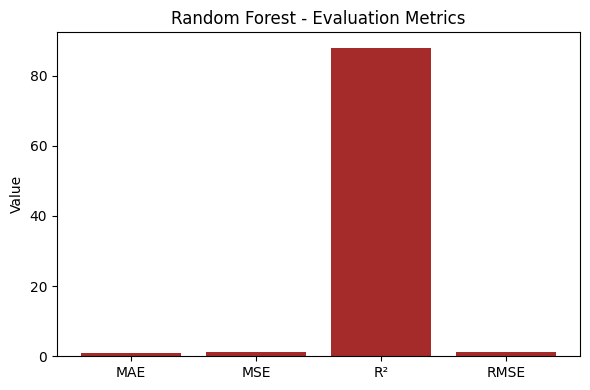


=== Cross-Validation Results (Training Data) ===
CV Mean R² Score: 0.8020
CV Mean RMSE: 1.4624
CV Mean MAE: 1.1018
CV Mean MSE: 2.2564


In [ ]:
# Create and train the model
# Train the Random Forest model
rf_reg = RandomForestRegressor(
    max_depth=8,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42)
rf_reg.fit(X_train_scaled, y_train)

# Predict on test data
pred_rf_reg = rf_reg.predict(X_test_scaled)

# Performance on Test Set
mse_rf = mean_squared_error(y_test, pred_rf_reg)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, pred_rf_reg)
r2_rf = r2_score(y_test, pred_rf_reg)

print("\n=== Test Set Performance ===")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

# Residuals
residual_rf = y_test - pred_rf_reg

# Collect into DataFrame
Error_RF = pd.DataFrame(
    [mae_rf, mse_rf, rmse_rf, r2_rf * 100],
    index=['MAE', 'MSE', 'RMSE', 'R2 (%)'],
    columns=['Random Forest']
)
print("\n=== Test Set Error Summary ===")
print(Error_RF)

# Plotting metrics
plt.figure(figsize=(6, 4))
plt.bar(['MAE', 'MSE', 'R²', 'RMSE'], [mae_rf, mse_rf, r2_rf * 100, rmse_rf], color='brown')
plt.title('Random Forest - Evaluation Metrics')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

# Cross-Validation with Multiple Metrics
cv_results = cross_validate(
    rf_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring={
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'mse': 'neg_mean_squared_error'
    }
)

cv_r2_mean = np.mean(cv_results['test_r2'])
cv_rmse_mean = -np.mean(cv_results['test_rmse'])
cv_mae_mean = -np.mean(cv_results['test_mae'])
cv_mse_mean = -np.mean(cv_results['test_mse'])

print("\n=== Cross-Validation Results (Training Data) ===")
print(f"CV Mean R² Score: {cv_r2_mean:.4f}")
print(f"CV Mean RMSE: {cv_rmse_mean:.4f}")
print(f"CV Mean MAE: {cv_mae_mean:.4f}")
print(f"CV Mean MSE: {cv_mse_mean:.4f}")

In [16]:
com_1 = pd.DataFrame({
    'Actual': y_test.ravel(),        # or y_test.flatten()
    'Predicted': pred_rf_reg .ravel() # or pred_lr_reg.flatten()
})
com_1.head()

,Actual,Predicted
0,8.255580,7.094505
1,0.000000,0.481405
2,2.987300,2.921989
3,3.010000,4.314981
4,1.186732,2.569277


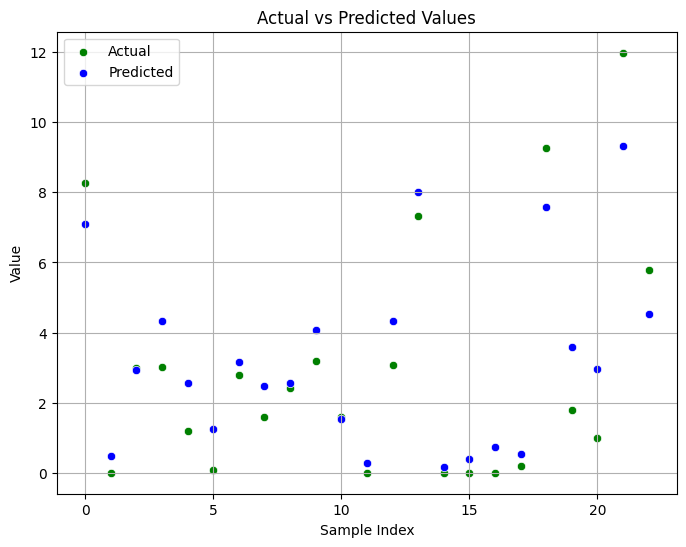

In [17]:
# Flatten
y_test_flat = y_test.ravel()
pred_rf_reg_flat = pred_rf_reg.ravel()

# Create scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(x=range(len(y_test_flat)), y=y_test_flat, color='green', label='Actual')
sns.scatterplot(x=range(len(pred_rf_reg_flat)), y=pred_rf_reg_flat, color='blue', label='Predicted')

plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## ================================
##  Support Vector Machine (SVM) Model
## ================================

CV Mean RMSE: 1.3187
Model testing performance:

Support Vector Regression Results:
--------------------------
Mean Squared Error: 1.2940695390470647
Root Mean Squared Error: 1.1375717731409587
Mean Squared Error: 0.8676264597972762
R2 Score: 88.02220842660627
--------------------------
Cross Validation MSE: 12.646205883950701
Cross Validation MSE: [-10.82050972  -7.18852804 -10.21801197 -16.23348072 -18.77049896]
--------------------------
Cross Validation MEAN R2: 0.8392920215183388
Cross Validation R2: [0.7175948  0.90042647 0.86326219 0.88102588 0.83415078]
--------------------------
            SVR
MAE    0.867626
MSE    1.294070
RMSE   1.137572
R2    88.022208
--------------------------


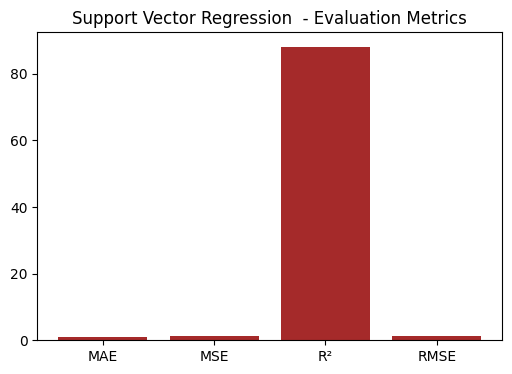

In [21]:
# Create and train the model
sv_reg = SVR(C= 8, epsilon=0.2, gamma='scale', kernel= 'rbf')
sv_reg.fit(X_train_scaled, y_train)  # Training the model on training data
pred_sv_reg = sv_reg.predict(X_test_scaled)  # Predicting on test data

# Cross-Validation
cv_sv = cross_val_score(sv_reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_sv_mean = -np.mean(cv_sv)


cv_svv = cross_val_score(sv_reg, X_train_scaled, y_train, cv=5, scoring='r2')
cv_svn = np.mean(cv_svv)


# Cross-Validation - RMSE
cv_rmseS = cross_val_score(sv_reg, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_meanN = -np.mean(cv_rmseS)  # Negate since scoring returns negative values for error metrics
print(f"CV Mean RMSE: {cv_rmse_meanN:.4f}")



# Residual Analysis
residual_sv = y_test - pred_sv_reg  # Ensure y_test and pred_sv_reg have the same length


# Performance Metrics
mse_sv = mean_squared_error(y_test, pred_sv_reg)
rmse_sv = np.sqrt(mse_sv)  # Corrected to use mse_sv, not mse_rf
mae_sv = mean_absolute_error(y_test, pred_sv_reg)
r2_sv = r2_score(y_test, pred_sv_reg)


# Print Results
print("Model testing performance:")
print("\nSupport Vector Regression Results:")
print("--------------------------")
print("Mean Squared Error:", mse_sv)
print("Root Mean Squared Error:", rmse_sv)
print("Mean Squared Error:", mae_sv)
print("R2 Score:", r2_sv*100)

print("--------------------------")

print("Cross Validation MSE:", cv_sv_mean)
print("Cross Validation MSE:", cv_sv)
print("--------------------------")

print("Cross Validation MEAN R2:", cv_svn)
print("Cross Validation R2:", cv_svv)




print("--------------------------")
sv = pd.DataFrame([mae_sv, mse_sv, rmse_sv,r2_sv*100], index=['MAE', 'MSE', 'RMSE', 'R2'], columns=['SVR'])
# Show the DataFrame
print(sv)



print("--------------------------")
# Plotting Results
plt.figure(figsize=(6, 4))
plt.bar(['MAE', 'MSE', 'R²', 'RMSE'], [mae_sv, mse_sv,r2_sv*100, rmse_sv], color='brown')
plt.title('Support Vector Regression  - Evaluation Metrics')
plt.show()

In [24]:
com_SV = pd.DataFrame({
    'Actual': y_test.ravel(),        # or y_test.flatten()
    'Predicted': pred_sv_reg.ravel() # or pred_lr_reg.flatten()
})
com_SV.head()

,Actual,Predicted
0,8.255580,7.887047
1,0.000000,-0.246190
2,2.987300,2.301098
3,3.010000,3.427793
4,1.186732,1.576240


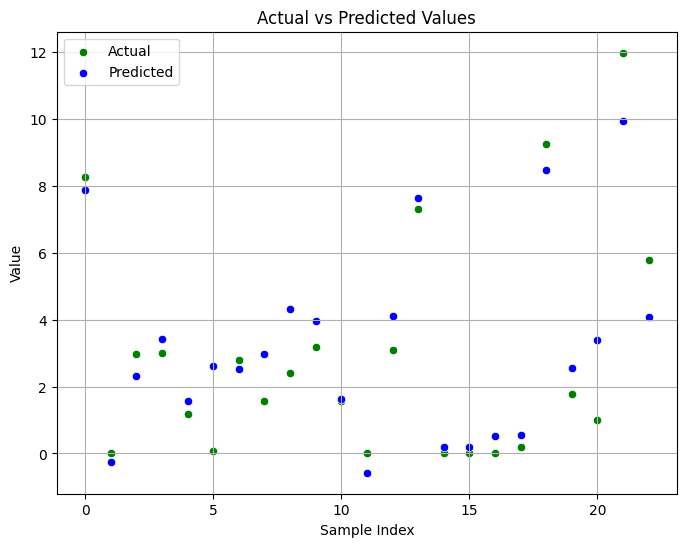

In [25]:
# Flatten
y_test_flat = y_test.ravel()
pred_sv_reg_flat = pred_sv_reg.ravel()

# Create scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(x=range(len(y_test_flat)), y=y_test_flat, color='green', label='Actual')
sns.scatterplot(x=range(len(pred_sv_reg_flat)), y=pred_sv_reg_flat, color='blue', label='Predicted')

plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## ================================
##  Neural Network Model
## ================================

Cross Validation MEAN R2: 0.768582242090189
Cross Validation R2: [0.71059371 0.70169155 0.81487608 0.97331821 0.64243165]
Model testing performance:

Neural Network Regression Results:
--------------------------
Mean Squared Error: 1.2007170465947785
Root Mean Squared Error: 1.095772351629105
Mean Squared Error: 0.9486961906169836
R2 Score: 88.88627072288263
--------------------------
Cross validation MEAN - MSE: 8807460266.511293
Cross validation- MSE: [-1.84183512e+01 -1.95842179e+10 -1.64278251e+01 -2.44507537e+10
 -2.32972072e+06]
--------------------------
Cross Validation MEAN R2: 0.768582242090189
Cross Validation R2: [0.71059371 0.70169155 0.81487608 0.97331821 0.64243165]
--------------------------
            MLP
MAE    0.948696
MSE    1.200717
RMSE   1.095772
R2    88.886271
--------------------------


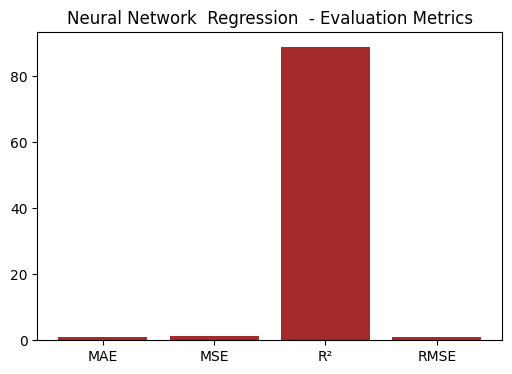

In [ ]:
# Create and train the model
mlp_reg = MLPRegressor(max_iter=1000, activation= 'relu', alpha=0.001, hidden_layer_sizes= (20, 10),
                       learning_rate_init= 0.1, early_stopping=True, validation_fraction=0.1, random_state=42)
mlp_reg.fit(X_train_scaled, y_train)  # Training the model on training data
pred_mlp_reg = mlp_reg.predict(X_test_scaled)  # Predicting on test data

# Cross-Validation
cv_mlp = cross_val_score(mlp_reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_mlp_mean = -np.mean(cv_mlp)


cv_mlpp = cross_val_score(mlp_reg, X_train_scaled, y_train, cv=5, scoring='r2')
cv_mlpp_mean = np.mean(cv_mlpp)

print("Cross Validation MEAN R2:", cv_mlpp_mean)
print("Cross Validation R2:", cv_mlpp )



# Residual Analysis
residual_mlp = y_test - pred_mlp_reg  # Ensure y_test and pred_sv_reg have the same length


# Performance Metrics
mse_mlp = mean_squared_error(y_test, pred_mlp_reg)
rmse_mlp = np.sqrt(mse_mlp)  # Corrected to use mse_sv, not mse_rf
mae_mlp = mean_absolute_error(y_test, pred_mlp_reg)
r2_mlp = r2_score(y_test, pred_mlp_reg)


# Print Results
print("Model testing performance:")
print("\nNeural Network Regression Results:")
print("--------------------------")
print("Mean Squared Error:", mse_mlp)
print("Root Mean Squared Error:", rmse_mlp)
print("Mean Squared Error:", mae_mlp)
print("R2 Score:", r2_mlp*100)

print("--------------------------")


print("Cross validation MEAN - MSE:", cv_mlp_mean)
print("Cross validation- MSE:", cv_mlp)
print("--------------------------")

print("Cross Validation MEAN R2:", cv_mlpp_mean)
print("Cross Validation R2:", cv_mlpp )


print("--------------------------")
mlp = pd.DataFrame([mae_mlp, mse_mlp, rmse_mlp,r2_mlp*100], index=['MAE', 'MSE', 'RMSE', 'R2'], columns=['MLP'])
# Show the DataFrame
print(mlp)



print("--------------------------")
# Plotting Results
plt.figure(figsize=(6, 4))
plt.bar(['MAE', 'MSE', 'R²', 'RMSE'], [mae_mlp, mse_mlp,r2_mlp*100, rmse_mlp], color='brown')
plt.title('Neural Network  Regression  - Evaluation Metrics')
plt.show()

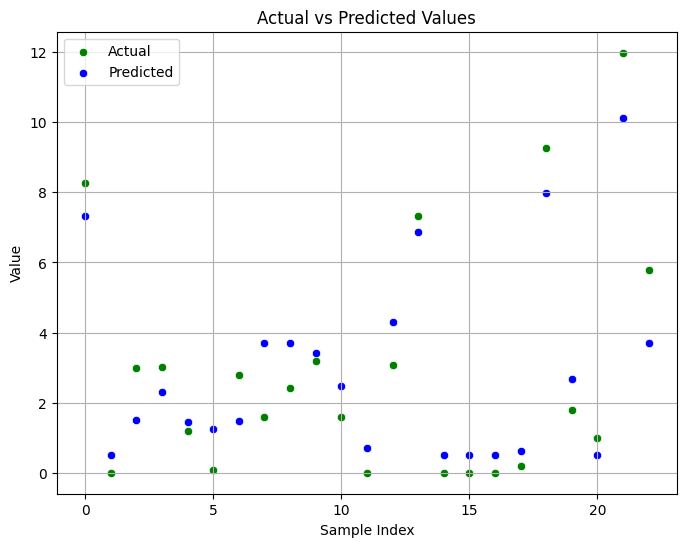

In [52]:
# Flatten
y_test_flat = y_test.ravel()
pred_mlp_reg_flat = pred_mlp_reg.ravel()

# Create scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(x=range(len(y_test_flat)), y=y_test_flat, color='green', label='Actual')
sns.scatterplot(x=range(len(pred_mlp_reg_flat)), y=pred_mlp_reg_flat, color='blue', label='Predicted')

plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## ================================
##  GBoost Model
## ================================

Model testing performance:

Gradient Boost Regression Results:
--------------------------
Mean Squared Error: 0.9298
Root Mean Squared Error: 0.9643
Mean Absolute Error: 0.7454
R2 Score: 91.39%
--------------------------
Cross-Validated Mean MSE: nan
Cross-Validated MSE: [0.6649663  0.82954531 0.8826286  0.83681557 0.76522469]
--------------------------
Cross-Validated R2: 0.8116992343287585
--------------------------
        Gradient Boosting
MAE              0.745438
MSE              0.929805
RMSE             0.964264
R2 (%)          91.393806
--------------------------


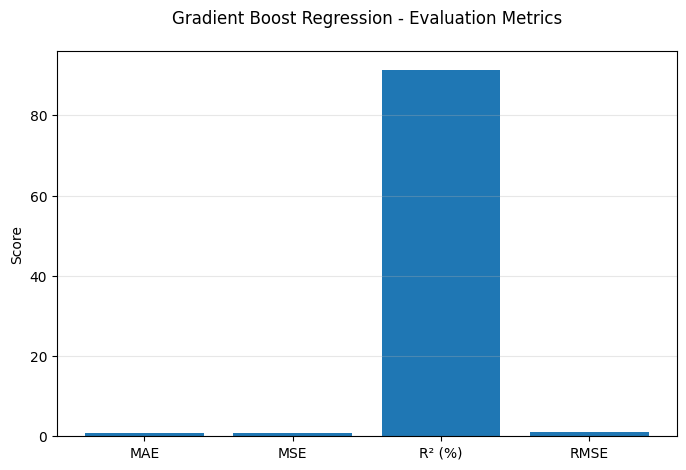

In [ ]:
# 1. Initialize and train Gradient Boosting model
gb_reg = GradientBoostingRegressor(
    n_estimators=200,  # Increased from default 100
    learning_rate=0.01,
    max_depth=5, subsample= 0.8,
    random_state=42,
     min_samples_split=5,    
      min_samples_leaf=1,
    )
gb_reg.fit(X_train_scaled, y_train)



#loss='huber',  # Robust to outliers
#min_samples_leaf=5,  # Prevents overfitting
    #n_estimators=200,       # Reduced from default (100) for small data
   # learning_rate=0.05,     # Lower learning rate for better generalization
   # max_depth=3,            # Shallower trees (critical for small datasets)
   # min_samples_split=5,    # Require more samples to split
   # min_samples_leaf=3,     # Require more samples per leaf
   # subsample=0.8,          # Stochastic boosting (80% of data per tree)
   # max_features='sqrt',    # Use √n_features per split
    #random_state=42


# 2. Predictions
y_pred_gb = gb_reg.predict(X_test_scaled)

# 3. Performance Metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)  # Fixed: Changed y_pred to y_pred_gb

# 4. Cross-Validation (5-fold)
cv_scores = cross_val_score(gb_reg, X_train, y_train, cv=5, scoring='r2')
cv_scores_mean = np.mean(np.sqrt(-cv_scores))


cv_mlpp = cross_val_score(gb_reg , X_train_scaled, y_train, cv=5, scoring='r2')
cv_mlpp_mean = np.mean(cv_mlpp)


# Print Results
print("Model testing performance:")
print("\nGradient Boost Regression Results:")
print("--------------------------")
print(f"Mean Squared Error: {mse_gb:.4f}")
print(f"Root Mean Squared Error: {rmse_gb:.4f}")
print(f"Mean Absolute Error: {mae_gb:.4f}")
print(f"R2 Score: {r2_gb*100:.2f}%")

print("--------------------------")
print(f"Cross-Validated Mean MSE: {cv_scores_mean}")  # Clarified this is cross-validated
print(f"Cross-Validated MSE: {cv_scores}")  # Clarified this is cross-validated

print("--------------------------")
print(f"Cross-Validated R2: {cv_mlpp_mean}")  # Clarified this is cross-validated




print("--------------------------")
gb = pd.DataFrame([mae_gb, mse_gb, rmse_gb, r2_gb*100], 
                 index=['MAE', 'MSE', 'RMSE', 'R2 (%)'], 
                 columns=['Gradient Boosting'])
print(gb)

print("--------------------------")
# Plotting Results
plt.figure(figsize=(8, 5))
plt.bar(['MAE', 'MSE', 'R² (%)', 'RMSE'], 
        [mae_gb, mse_gb, r2_gb*100, rmse_gb], 
        color='#1f77b4')  # Changed to standard blue
plt.title('Gradient Boost Regression - Evaluation Metrics', pad=20)
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

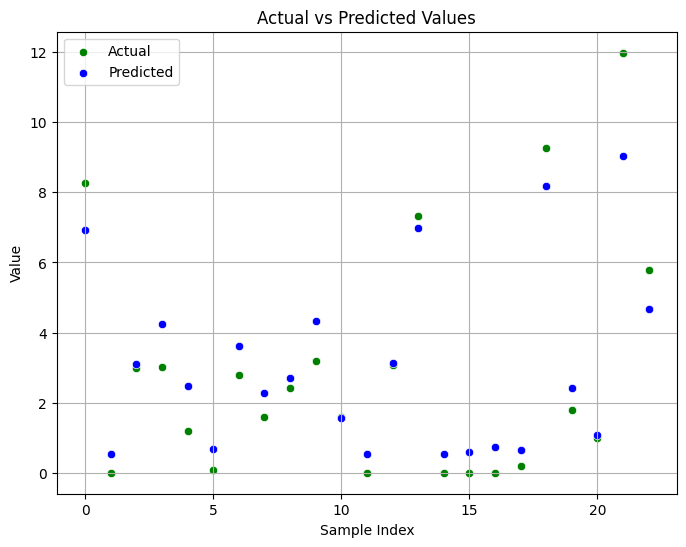

In [91]:
# Flatten
y_test_flat = y_test.ravel()
pred_gb_reg_flat = y_pred_gb.ravel()

# Create scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(x=range(len(y_test_flat)), y=y_test_flat, color='green', label='Actual')
sns.scatterplot(x=range(len(pred_gb_reg_flat)), y=pred_gb_reg_flat, color='blue', label='Predicted')

plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [75]:

n1 = [y_pred_gb,y_test]
n3=['Predict','Actual']

In [76]:
def hist_seaborn(n1, n3):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    
    for i in range(2):
        sns.histplot(n1[i], kde=True, color='purple', ax=axes[i])
        axes[i].set_xlabel(f'{n3[i]} Values')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Distribution of {n3[i]} Values')
    
    plt.tight_layout()
    plt.show()

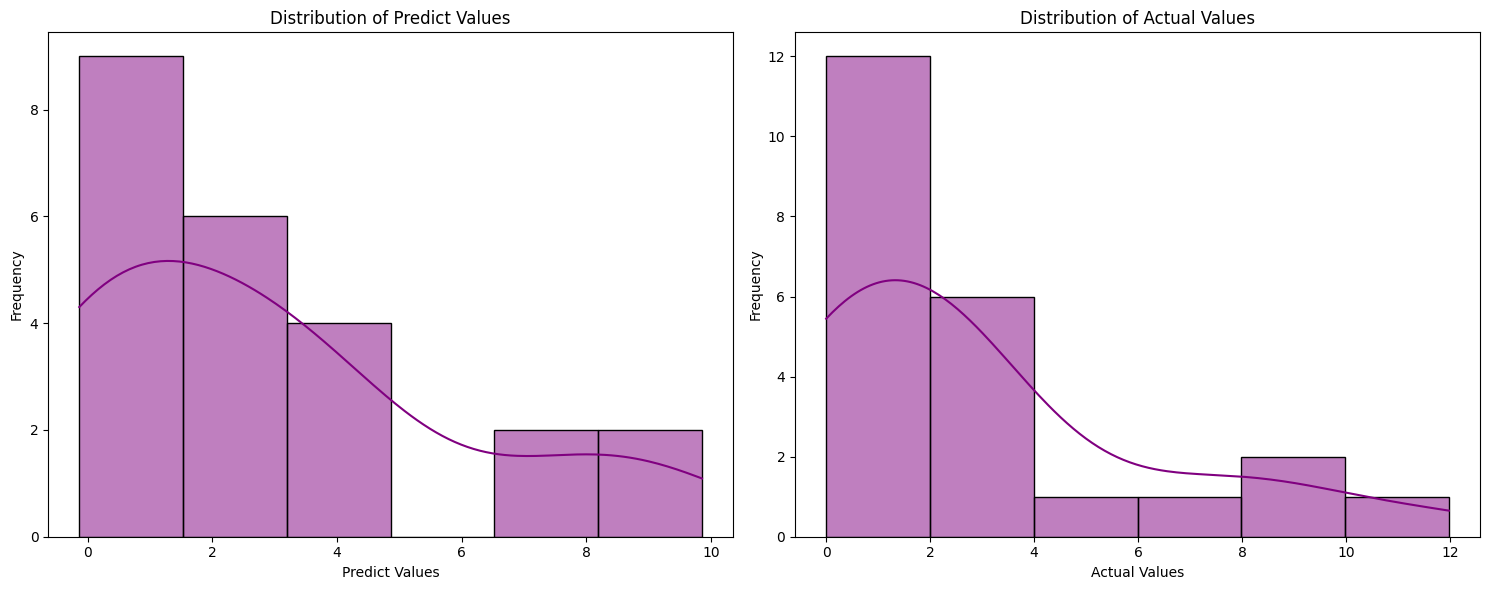

In [77]:
hist_seaborn(n1,n3)

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">K-Fold Cross-Validation (CV)</p>
</div>

In [ ]:
models ={
'SVR': SVR(C= 8, epsilon=0.2, gamma='scale', kernel= 'rbf'),
    'RF': RandomForestRegressor(max_depth=8,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42),
    'ANN': MLPRegressor(max_iter=1000, activation= 'relu', alpha=0.001, hidden_layer_sizes= (20, 10),
                       learning_rate_init= 0.1, early_stopping=True, validation_fraction=0.1, random_state=42),
    'GBoost': GradientBoostingRegressor(
        n_estimators=200,  # Increased from default 100 metahnol
    learning_rate=0.01,
    max_depth=5, subsample= 0.8,
    random_state=42,
     min_samples_split=5,    
      min_samples_leaf=1)}

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
    print(f"📌 {name} Cross-validation R² Scores: {scores}")
    print(f"➡️  Mean R² Score: {np.mean(scores):.4f}")
    print("-" * 50)

📌 SVR Cross-validation R² Scores: [0.75878778 0.9289959  0.79988526 0.81375486 0.90398697]
➡️  Mean R² Score: 0.8411
--------------------------------------------------
📌 RF Cross-validation R² Scores: [0.80206986 0.85451661 0.71292386 0.72846243 0.8232588 ]
➡️  Mean R² Score: 0.7842
--------------------------------------------------
📌 ANN Cross-validation R² Scores: [0.77627453 0.8118115  0.28304214 0.44042926 0.75989635]
➡️  Mean R² Score: 0.6143
--------------------------------------------------
📌 GBoost Cross-validation R² Scores: [0.69305192 0.83053933 0.70153811 0.75201437 0.85112177]
➡️  Mean R² Score: 0.7657
--------------------------------------------------


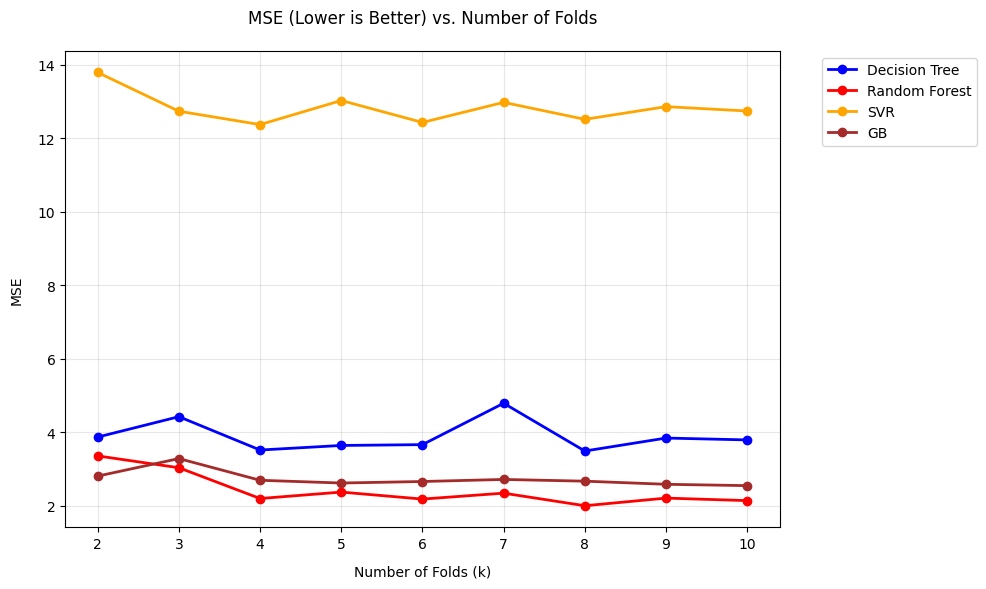

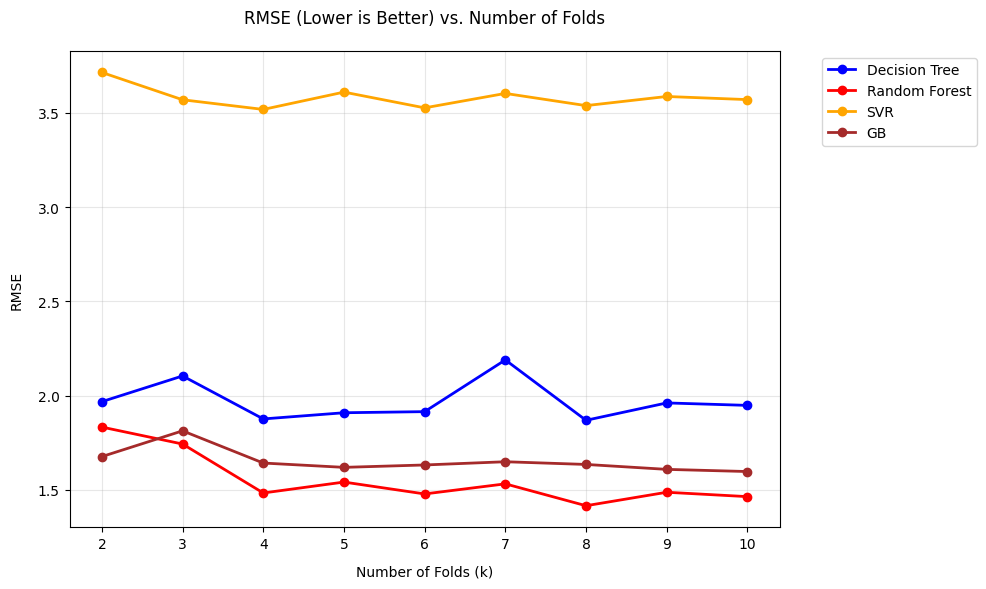

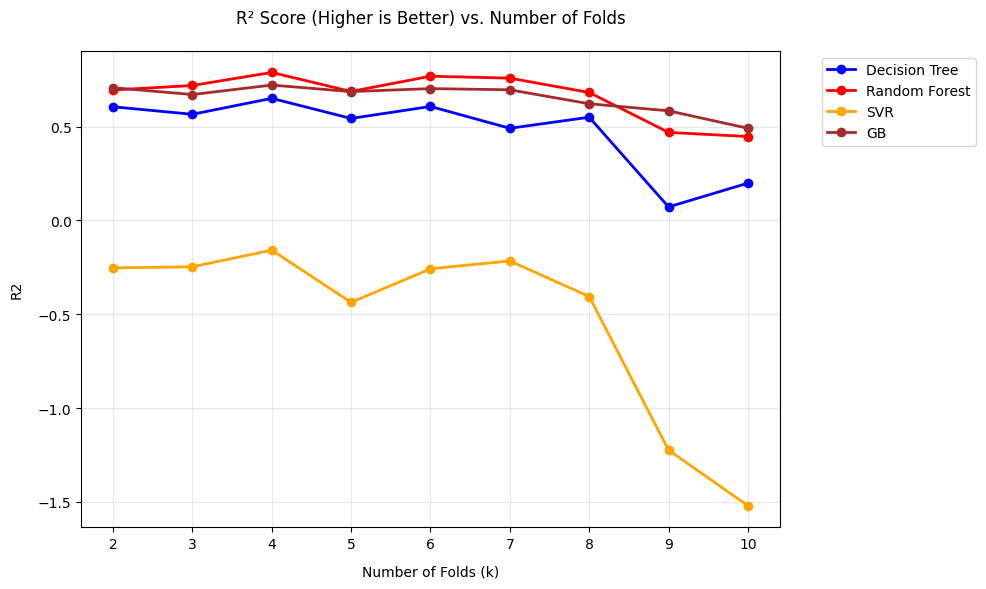

In [48]:
from sklearn.metrics import mean_squared_error, make_scorer

# Define color scheme for models
model_colors = {
    "Decision Tree": "blue",
    "Random Forest": "red",
    "Linear Regression": "green",
    "MLP": "purple",
    "SVR": "orange",
    "GB": "brown"
}

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Define models
models = {
    "Decision Tree":  DecisionTreeRegressor(max_depth= 10, max_features= None, min_samples_leaf=1, min_samples_split= 2),
    "Random Forest": RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=1, 
                               min_samples_split=2, n_estimators=200),
    "MLP": MLPRegressor(max_iter=1000, activation= 'relu', alpha=0.001, hidden_layer_sizes= (30, 15),
                       learning_rate_init= 0.001, early_stopping=True, validation_fraction=0.1),
    'SVR': SVR(C= 10, epsilon=0.2, gamma='scale', kernel= 'rbf'),
    'GB': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
    
}

# 3. Prepare storage
ks = range(2, 11)
results = {name: {'mse': [], 'rmse': [], 'r2': []} for name in models}

# 4. Cross-validation loop
for k in ks:
    cv = KFold(n_splits=k, shuffle=True, random_state=42)
    for name, model in models.items():
        cvres = cross_validate(
            model, X_train, y_train, cv=cv,
            scoring={
                'r2': 'r2',
                'mse': make_scorer(mean_squared_error, greater_is_better=False)
            },
            return_train_score=False
        )
        mse_mean = -np.mean(cvres['test_mse'])
        results[name]['mse'].append(mse_mean)
        results[name]['rmse'].append(np.sqrt(mse_mean))
        results[name]['r2'].append(np.mean(cvres['test_r2']))

# 5. Plot results with customized colors
metrics = {
    'mse': 'MSE (Lower is Better)',
    'rmse': 'RMSE (Lower is Better)',
    'r2': 'R² Score (Higher is Better)'
}

for metric, title in metrics.items():
    plt.figure(figsize=(10, 6))
    for name in models:
        plt.plot(ks, results[name][metric], 
                marker='o', 
                linewidth=2,
                color=model_colors[name],
                label=name)
    
    plt.title(f"{title} vs. Number of Folds", pad=20)
    plt.xlabel("Number of Folds (k)", labelpad=10)
    plt.ylabel(metric.upper(), labelpad=10)
    plt.xticks(ks)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Feature selection</p>
</div>

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.head(15))

                                    Feature  Importance
3                                        FE    0.645926
12                    Current Density/mAcm2    0.162935
21                                    Power    0.046818
13                       Reaction Time (hr)    0.043320
9                  Light Intensity (mV/cm2)    0.020648
20                              Pt Ni_Ratio    0.011172
8               C/S Ratio(catalyst/Support)    0.009394
24  Ink-I/C Ratio(ionomer/catalyst) Encoded    0.008335
6                         TiO2 % as support    0.006639
22                   Reducing agent Encoded    0.005898
1                   Co at% in metal element    0.005254
11                   Voltage (v vs Ag/AgCl)    0.004063
0                   Pt at% in metal element    0.003662
5                 (NG) at% in metal element    0.003065
14                              Solar light    0.002936


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> hyperpearameter Optimization</p>
</div>

## Lets fine tune Random Forest

In [272]:
from sklearn.model_selection import GridSearchCV

--------------------------
Best Hyperparameters for Random Forest: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RMSE from GridSearchCV: 2.256442957384047
--------------------------
Random Forest - R² Score: 0.8793696996684637
Random Forest - MSE: 1.3032786235143223
Random Forest - RMSE: 1.1416122912417868
Random Forest - MAE: 0.9211147346632792
RF 5-fold CV R²: 0.7995193987677248


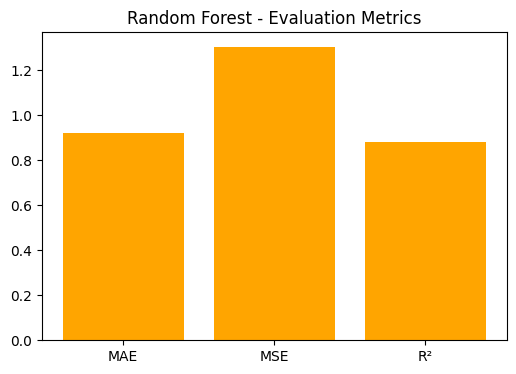

In [ ]:

# Random Forest with GridSearchCV
model_rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 5, 6,8, 10],
    'min_samples_split': [2, 4, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['auto', 'sqrt']}
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

# Best parameters and best score
best_params_rf = grid_rf.best_params_
best_rmse_rf = -grid_rf.best_score_


# Best model
best_model_rf = grid_rf.best_estimator_
y_pred = best_model_rf.predict(X_test_scaled)


# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



print("--------------------------")

print(f"Best Hyperparameters for Random Forest: {best_params_rf}")
print(f"Best RMSE from GridSearchCV: {best_rmse_rf}")


print("--------------------------")
# Print Results
print(f'Random Forest - R² Score: {r2}')
print(f'Random Forest - MSE: {mse}')
print(f'Random Forest - RMSE: {np.sqrt(mse)}')
print(f'Random Forest - MAE: {mae}')

# 5-fold CV on the best RF
cv_scores_rf = cross_val_score(best_model_rf, X_train, y_train, cv=5, scoring='r2')
print("RF 5-fold CV R²:", cv_scores_rf.mean())



# Plotting Results
plt.figure(figsize=(6, 4))
plt.bar(['MAE', 'MSE', 'R²'], [mae, mse, r2], color='orange')
plt.title('Random Forest - Evaluation Metrics')
plt.show()


##  Lets fine tune Gradient Boosting

--------------------------
Best Hyperparameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}
Best RMSE from GridSearchCV: 1.776625578204912
--------------------------
Gradient Boosting - Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}
Gradient Boosting - R² Score: 0.9456892960737294
Gradient Boosting - RMSE: 0.766007721337696
--------------------------
GB 5-fold CV R²: 0.8244219311176508


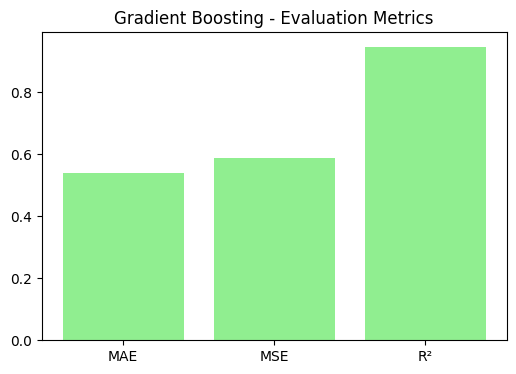

In [ ]:


# Gradient Boosting with GridSearchCV
model_gb = GradientBoostingRegressor(random_state=42)
param_grid_gb = {
     'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3]  }

#loss='huber',  # Robust to outliers
#min_samples_leaf=5,  # Prevents overfitting
    #n_estimators=200,       # Reduced from default (100) for small data
   # learning_rate=0.05,     # Lower learning rate for better generalization
   # max_depth=3,            # Shallower trees (critical for small datasets)
   # min_samples_split=5,    # Require more samples to split
   # min_samples_leaf=3,     # Require more samples per leaf
   # subsample=0.8,          # Stochastic boosting (80% of data per tree)
   # max_features='sqrt',    # Use √n_features per split
    #random_state=42

grid_gb = GridSearchCV(model_gb, param_grid_gb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train_scaled, y_train)

# Best parameters and best score
best_params_gb = grid_gb.best_params_
best_rmse_gb = -grid_gb.best_score_



# Best model
best_model = grid_gb.best_estimator_
y_pred_gb = best_model.predict(X_test_scaled)

# Evaluation Metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)


print("--------------------------")

print(f"Best Hyperparameters for Gradient Boosting: {best_params_gb}")
print(f"Best RMSE from GridSearchCV: {best_rmse_gb}")

print("--------------------------")

# Print Results
print(f'Gradient Boosting - Best Parameters: {grid_gb.best_params_}')
print(f'Gradient Boosting - R² Score: {r2_gb}')
print(f'Gradient Boosting - RMSE: {np.sqrt(mse_gb)}')


print("--------------------------")

# 5-fold CV on the best  GB
cv_scores_gb = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print("GB 5-fold CV R²:", cv_scores_gb.mean())



# Plotting Results
plt.figure(figsize=(6, 4))
plt.bar(['MAE', 'MSE', 'R²'], [mae_gb, mse_gb, r2_gb], color='lightgreen')
plt.title('Gradient Boosting - Evaluation Metrics')
plt.show()






## Lets fine tune MLP

Fitting 5 folds for each of 108 candidates, totalling 540 fits
--------------------------
Best Hyperparameters for MLP: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (20, 10), 'learning_rate_init': 0.1}
Best RMSE from GridSearchCV: 1.456247537312856
--------------------------
MLP - R² Score: 0.8252369684453891
MLP - RMSE: 1.3740901178653837
--------------------------
 Train-Mean CV R score: 0.6142907553469097
--------------------------
 Train_scale-Mean CV RMSE: 5.203383845931951
--------------------------
Max Intitiaor: 1000


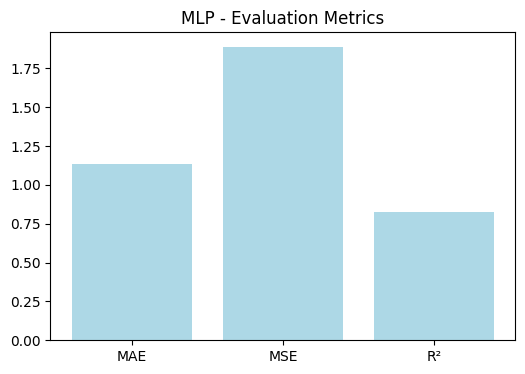

In [83]:


mlp = MLPRegressor(random_state=42, solver='adam', max_iter=1000, early_stopping=True, validation_fraction=0.1)
#Set max_iter high enough (e.g., 2000) and use early_stopping=True

# Step 5: Define the parameter grid for GridSearchCV
param_grid_mlp = {
    'hidden_layer_sizes': [(20,), (30,), (20, 10), (30, 15)],  # Hidden layer configurations
    'activation': ['relu', 'tanh', 'logistic'],  # Corrected activation functions
    'learning_rate_init': [0.001, 0.01, 0.1],  # Learning rates
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization (weight decay)
}

# Step 6: Perform grid search with cross-validation
grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring='neg_root_mean_squared_error',  #'neg_mean_squared_error', 'r2','neg_root_mean_squared_error' for consistency:
    cv=5,
    verbose=1,
    n_jobs=-1  # Use all CPU cores for parallel computation
)

grid_mlp.fit(X_train_scaled, y_train)


# Best parameters and best score
best_params_mlp = grid_mlp.best_params_
best_rmse_mlp = -grid_mlp.best_score_




#  best model on the test set
best_mlp = grid_mlp.best_estimator_
y_pred = best_mlp.predict(X_test_scaled)

# Evaluation Metrics
mae_mlp = mean_absolute_error(y_test, y_pred)
mse_mlp = mean_squared_error(y_test, y_pred)
r2_mlp = r2_score(y_test, y_pred)


print("--------------------------")
#print(f"Best R² Score (during cross-validation): {grid_search.best_score_}")
print(f"Best Hyperparameters for MLP: {best_params_mlp}")
print(f"Best RMSE from GridSearchCV: {best_rmse_mlp}")


print("--------------------------")
# Print Results
print(f'MLP - R² Score: {r2_mlp}')
print(f'MLP - RMSE: {np.sqrt(mse_mlp)}')


print("--------------------------")
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# 5-fold CV on the best MLP
cv_rmse_scores = cross_val_score(best_mlp, X_train_scaled, y_train, scoring='r2', cv=cv)
print(" Train-Mean CV R score:", np.mean(cv_rmse_scores))  # Use negative sign to make it positive

print("--------------------------")

cv_rmse_scoress = cross_val_score(best_mlp, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv)
print(" Train_scale-Mean CV RMSE:", -np.mean(cv_rmse_scoress))  # Use negative sign to make it positive

print("--------------------------")

print(f'Max Intitiaor: {grid_mlp.best_estimator_.max_iter}')


# Plotting Results
plt.figure(figsize=(6, 4))
plt.bar(['MAE', 'MSE', 'R²'], [mae_mlp, mse_mlp, r2_mlp], color='lightblue')
plt.title('MLP - Evaluation Metrics')
plt.show()



<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Comparasion Models</p>
</div>

In [ ]:
# Define models
models = {
'SVR': SVR(C= 10, epsilon=0.2, gamma='scale', kernel= 'rbf'),
    'RF': RandomForestRegressor(max_depth=6, max_features='sqrt', min_samples_leaf=1, 
                               min_samples_split=2, n_estimators=300, random_state=42),
    'ANN': MLPRegressor(max_iter=1000, activation= 'relu', alpha=0.001, hidden_layer_sizes= (20, 10),
                       learning_rate_init= 0.1, early_stopping=True, validation_fraction=0.1),
    'GBoost': GradientBoostingRegressor(
        n_estimators=200,  # Increased from default 100
    learning_rate=0.01,
    max_depth=5, subsample= 0.8,
    random_state=42,
     min_samples_split=5,    
      min_samples_leaf=1 )}
 
# Fit models and collect predictions
predictions = {}
metrics = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    predictions[name] = {'train': y_train_pred, 'test': y_test_pred}

    metrics[name] = {
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)}

# Print metrics table
print("{:<20} {:<15} {:<15} {:<15} {:<15} {:<15} {:<15}".format(
    'Model', 'Train R²', 'Test R²', 'Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE'))
print("-" * 120)

for model, vals in metrics.items():
    print("{:<20} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}".format(
        model, vals['Train R²'], vals['Test R²'],
        vals['Train RMSE'], vals['Test RMSE'],
        vals['Train MAE'], vals['Test MAE'] ))


Model                Train R²        Test R²         Train RMSE      Test RMSE       Train MAE       Test MAE       
------------------------------------------------------------------------------------------------------------------------
SVR                  0.9805          0.8894          0.4750          1.0931          0.3351          0.8130         
RF                   0.9514          0.8748          0.7505          1.1628          0.5814          0.9293         
ANN                  0.9548          0.8849          0.7235          1.1151          0.5223          0.9207         
GBoost               0.9670          0.9139          0.6181          0.9643          0.5003          0.7454         


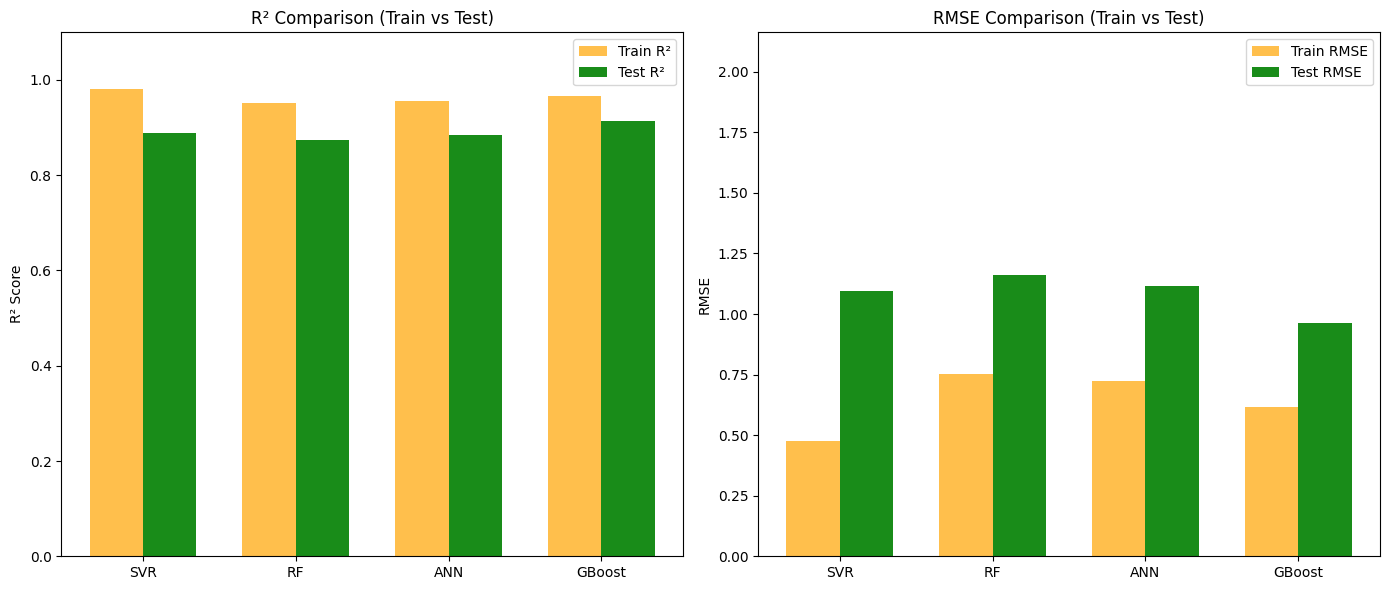

In [112]:
# Extract data for plots
model_names = list(metrics.keys())
train_r2 = [metrics[m]['Train R²'] for m in model_names]
test_r2 = [metrics[m]['Test R²'] for m in model_names]
train_rmse = [metrics[m]['Train RMSE'] for m in model_names]
test_rmse = [metrics[m]['Test RMSE'] for m in model_names]

# Consistent color for RMSE bars
train_color = "orange"  # blue
test_color = "green"   # orange



#rain_color = "#4AF00834"  # blue
#test_color = "#ff0e0e"   # orange
#colors = ['blue', 'orange', 'green', 'red', 'pink']


# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² Comparison
bar_width = 0.35
x = range(len(model_names))
axes[0].bar([i - bar_width/2 for i in x], train_r2, width=bar_width, label='Train R²', alpha=0.7, color=train_color)
axes[0].bar([i + bar_width/2 for i in x], test_r2, width=bar_width, label='Test R²', alpha=0.9, color=test_color)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_title('R² Comparison (Train vs Test)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# RMSE Comparison
axes[1].bar([i - bar_width/2 for i in x], train_rmse, width=bar_width, label='Train RMSE', alpha=0.7, color=train_color)
axes[1].bar([i + bar_width/2 for i in x], test_rmse, width=bar_width, label='Test RMSE', alpha=0.9, color=test_color)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_title('RMSE Comparison (Train vs Test)')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(0, max(max(train_rmse), max(test_rmse)) + 1)
axes[1].legend()

plt.tight_layout()
plt.show()

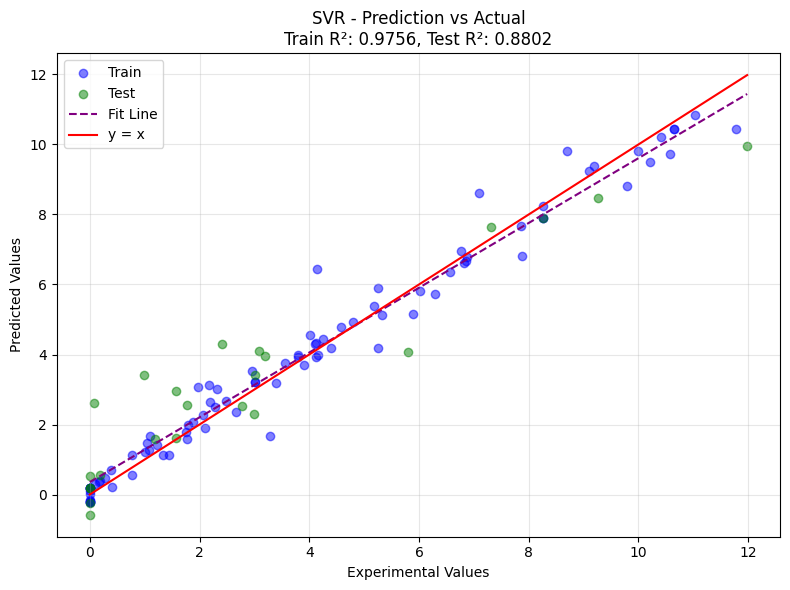

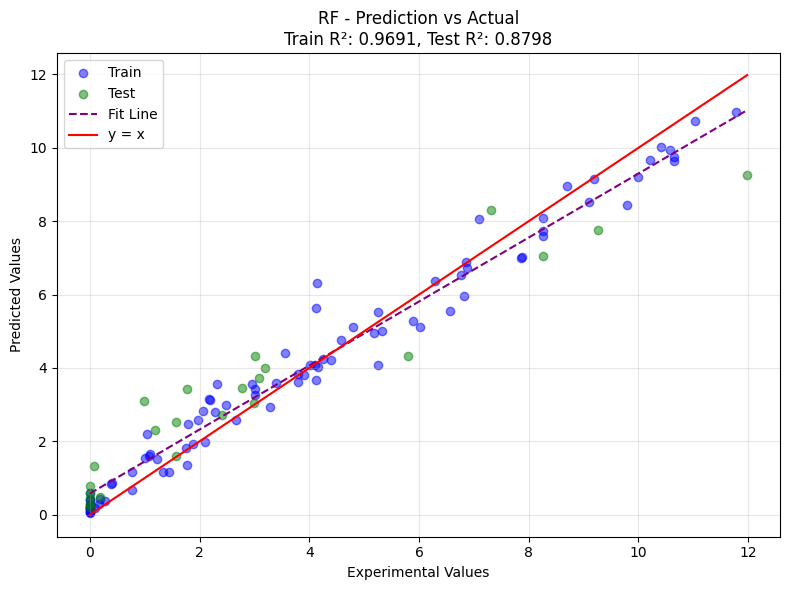

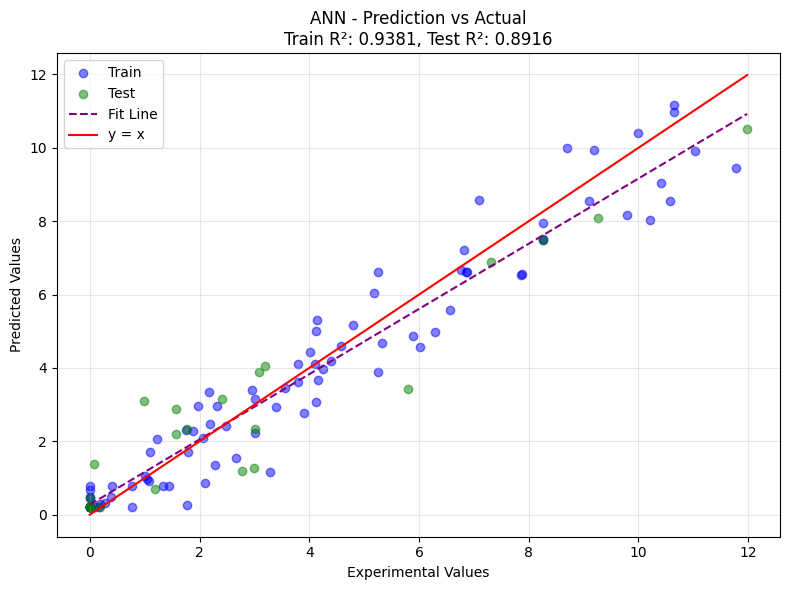

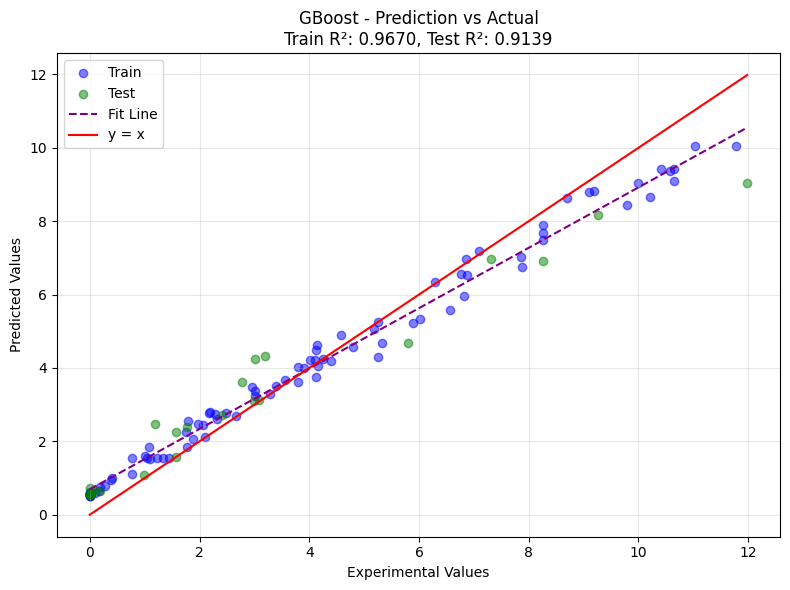

    Model  Train R²   Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE
0     SVR  0.975603  0.880222    0.531708   1.137572   0.368350  0.867626
1      RF  0.969120  0.879800    0.598201   1.139574   0.451986  0.930244
2     ANN  0.938065  0.891647    0.847182   1.081961   0.645781  0.883834
3  GBoost  0.967032  0.913938    0.618099   0.964264   0.500260  0.745438


In [ ]:


# Define models
models={
'SVR': SVR(C= 8, epsilon=0.2, gamma='scale', kernel= 'rbf'),
    'RF': RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=1, 
                               min_samples_split=2, n_estimators=300),
    'ANN': MLPRegressor(max_iter=1000, activation= 'relu', alpha=0.001, hidden_layer_sizes= (30, 15),
                       learning_rate_init= 0.1, early_stopping=True, validation_fraction=0.1),
    'GBoost': GradientBoostingRegressor(
        n_estimators=200,  # Increased from default 100
    learning_rate=0.01,
    max_depth=5, subsample= 0.8,
    random_state=42,
     min_samples_split=5,    
      min_samples_leaf=1)}


## Create results table
results = []

# Evaluate each model
for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Store results
    results.append({
        "Model": name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": train_mae,
        "Test MAE": test_mae})
    
    # Convert y values to numpy arrays for reshaping
    y_train_np = np.array(y_train)
    y_test_np = np.array(y_test)

    # Combine train and test data for fitting
    y_all_actual = np.concatenate([y_train, y_test])
    y_all_pred = np.concatenate([y_train_pred, y_test_pred])

    # Fit a linear regression model for the combined data
    fit_model = LinearRegression().fit(y_all_actual.reshape(-1, 1), y_all_pred)
    fit_line = fit_model.predict(np.array([y_all_actual.min(), y_all_actual.max()]).reshape(-1, 1))

    # Scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train, y_train_pred, alpha=0.5, label='Train', c='blue')
    plt.scatter(y_test, y_test_pred, alpha=0.5, label='Test', c='green')

    # Plot the fitted line for combined data
    plt.plot([y_all_actual.min(), y_all_actual.max()], fit_line, 'purple', linestyle='--', label='Fit Line')

    # Plot the y = x line
    min_val = min(y_train_np.min(), y_test_np.min())
    max_val = max(y_train_np.max(), y_test_np.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r-', label='y = x')

    # Labels and title
    plt.xlabel('Experimental Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name} - Prediction vs Actual\nTrain R²: {train_r2:.4f}, Test R²: {test_r2:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Results summary
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

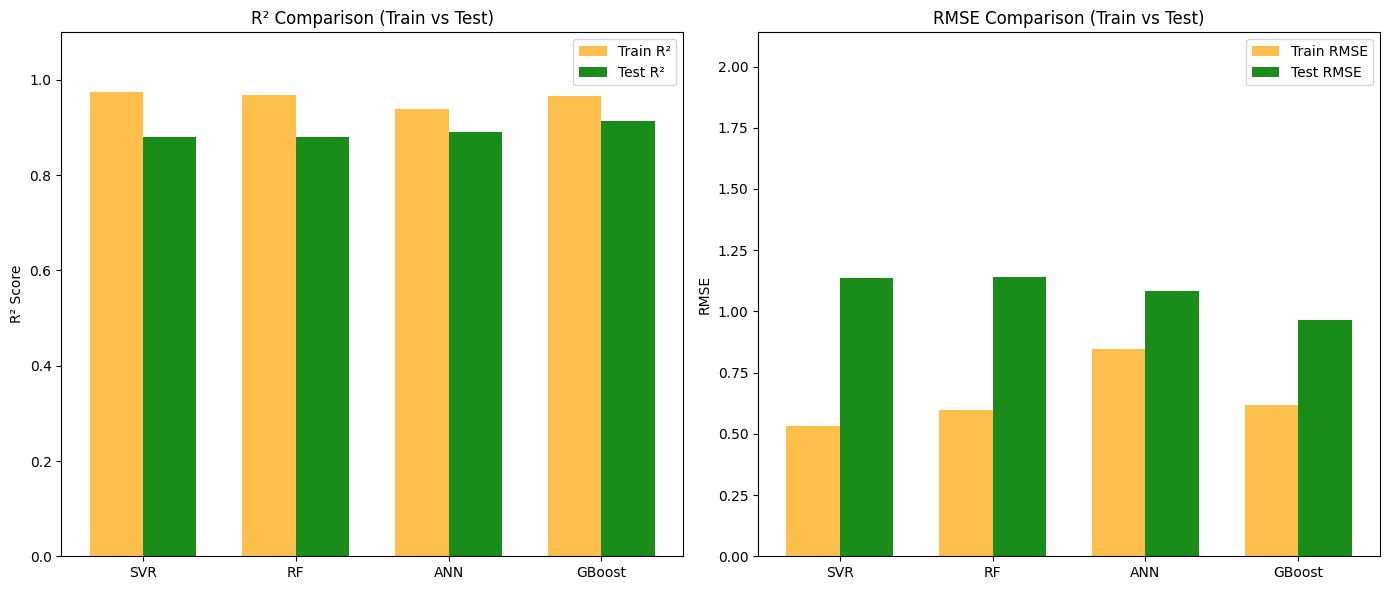

In [138]:
# Extract data for plots from results_df
model_names = results_df['Model']
train_r2 = results_df['Train R²']
test_r2 = results_df['Test R²']
train_rmse = results_df['Train RMSE']
test_rmse = results_df['Test RMSE']

# Consistent colors for RMSE bars
train_color = "orange"
test_color = "green"

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bar_width = 0.35
x = np.arange(len(model_names))

# R² Comparison
axes[0].bar(x - bar_width/2, train_r2, width=bar_width, label='Train R²', alpha=0.7, color=train_color)
axes[0].bar(x + bar_width/2, test_r2, width=bar_width, label='Test R²', alpha=0.9, color=test_color)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_title('R² Comparison (Train vs Test)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# RMSE Comparison
axes[1].bar(x - bar_width/2, train_rmse, width=bar_width, label='Train RMSE', alpha=0.7, color=train_color)
axes[1].bar(x + bar_width/2, test_rmse, width=bar_width, label='Test RMSE', alpha=0.9, color=test_color)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_title('RMSE Comparison (Train vs Test)')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(0, max(max(train_rmse), max(test_rmse)) + 1)
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Feature Importnat</p>
</div>

In [7]:
# 1. Drop the 'FE' feature from X
X_1 = X.drop(columns=['FE','Has_Ni','Electrolyzer'])

# 2. Define the feature names after dropping 'FE'
feature_names = X_1.columns  # Now the feature names no longer include 'FE'

# 3. Ensure that scaling is applied to the correct features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[feature_names])
X_test_scaled = scaler.transform(X_test[feature_names])


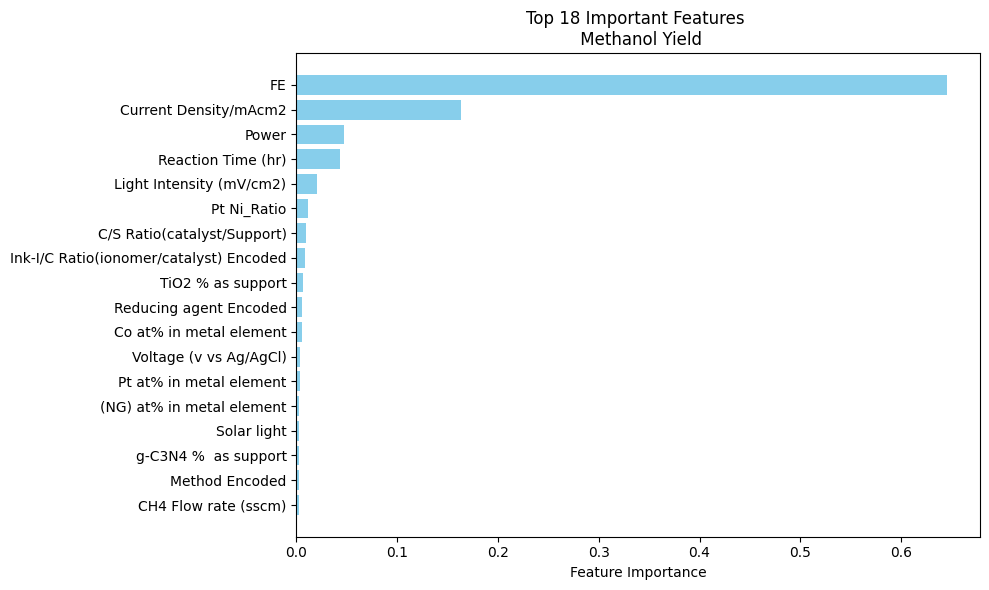


📌 Top 18 Feature Importances (Random Forest):
FE: 0.6459
Current Density/mAcm2: 0.1629
Power: 0.0468
Reaction Time (hr): 0.0433
Light Intensity (mV/cm2): 0.0206
Pt Ni_Ratio: 0.0112
C/S Ratio(catalyst/Support): 0.0094
Ink-I/C Ratio(ionomer/catalyst) Encoded: 0.0083
TiO2 % as support: 0.0066
Reducing agent Encoded: 0.0059
Co at% in metal element: 0.0053
Voltage (v vs Ag/AgCl): 0.0041
Pt at% in metal element: 0.0037
(NG) at% in metal element: 0.0031
Solar light: 0.0029
g-C3N4 %  as support: 0.0027
Method Encoded: 0.0027
CH4 Flow rate (sscm): 0.0024


In [96]:

# Fit RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Get feature importances and names
rf_importances = rf_model.feature_importances_

# Create DataFrame and sort by importance
rf_feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 features for RandomForest
top_n = 18
top_rf_features = rf_feat_imp_df.head(top_n)

# Plot RandomForest feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_rf_features['Feature'], top_rf_features['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Important Features \n Methanol Yield')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Optional: Print top features for RandomForest
print(f"\n📌 Top {top_n} Feature Importances (Random Forest):")
for i, row in top_rf_features.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

In [89]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [ ]:


# 1. Drop unwanted columns
X_1 = X.drop(columns=['FE','Has_Ni','Has_Co','Pt Ni_Ratio','Has_Pt','Ink-I/C Ratio(ionomer/catalyst) Encoded','C/S Ratio(catalyst/Support)',
                      'Solar light', 'Power','(Ti3CN-MX) at% in metal element','(NG) at% in metal element', 'Electrolyzer'])

# 2. Update feature names
feature_names = X_1.columns

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[feature_names])
X_test_scaled = scaler.transform(X_test[feature_names])

# 4. Fit the Gradient Boosting model
gb_model = GradientBoostingRegressor( n_estimators=200,  # Increased from default 100
    learning_rate=0.01,
    max_depth=5, subsample= 0.8,
    random_state=42,
     min_samples_split=5,    
      min_samples_leaf=1)
gb_model.fit(X_train_scaled, y_train)

# 5. Get feature importances
gb_importances = gb_model.feature_importances_

# 6. Create DataFrame
gb_feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_importances
}).sort_values(by='Importance', ascending=False)

# 7. Get top N features
top_n = 30
top_gb_features = gb_feat_imp_df.head(top_n)

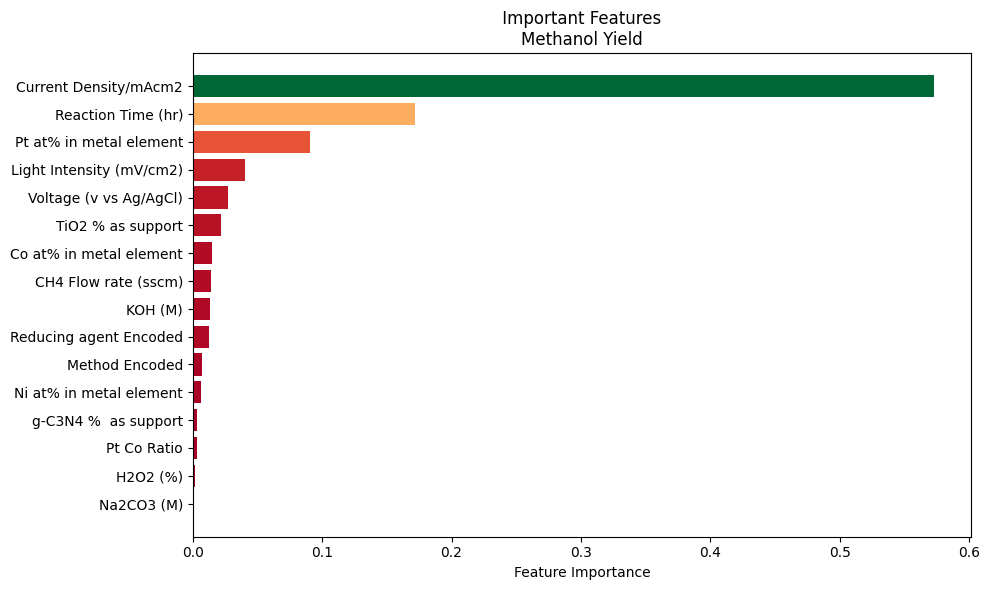


📌 Top 30 Feature Importances (Gradient Boosting):
Current Density/mAcm2: 0.5728
Reaction Time (hr): 0.1714
Pt at% in metal element: 0.0904
Light Intensity (mV/cm2): 0.0404
Voltage (v vs Ag/AgCl): 0.0270
TiO2 % as support: 0.0216
Co at% in metal element: 0.0147
CH4 Flow rate (sscm): 0.0144
KOH (M): 0.0130
Reducing agent Encoded: 0.0124
Method Encoded: 0.0071
Ni at% in metal element: 0.0063
g-C3N4 %  as support: 0.0034
Pt Co Ratio: 0.0032
H2O2 (%): 0.0014
Na2CO3 (M): 0.0005


In [113]:
import matplotlib.cm as cm

norm = plt.Normalize(top_gb_features['Importance'].min(), top_gb_features['Importance'].max())
colors = cm.RdYlGn(norm(top_gb_features['Importance']))

plt.figure(figsize=(10, 6))
plt.barh(top_gb_features['Feature'], top_gb_features['Importance'], color=colors)
plt.xlabel('Feature Importance')
plt.title(f' Important Features \nMethanol Yield')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top features
print(f"\n📌 Top {top_n} Feature Importances (Gradient Boosting):")
for i, row in top_gb_features.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

In [125]:
df.to_excel('preprocessed_data4.xlsx', index=False)